# Artificial Intelligence — Exercise 1
## International Football Results Analysis (1872–2024)

**Dataset:** [Kaggle — International Football Results](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)

This notebook performs a comprehensive analysis of international football match results, covering:
1. Basic Exploration
2. Goals Analysis
3. Match Results & Home Advantage
4. Visualizations

---
## Step 1: Load the CSV and Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid')

# Load dataset
df = pd.read_csv('../data/results.csv')
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [2]:
# Quick overview of the dataset
print("Dataset Info:")
print(f"  Rows: {df.shape[0]:,}")
print(f"  Columns: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset Info:
  Rows: 49,287
  Columns: 9

Column names: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

Data types:
date           object
home_team      object
away_team      object
home_score    float64
away_score    float64
tournament     object
city           object
country        object
neutral          bool
dtype: object

Missing values:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


---
## Part 1: Basic Exploration

### Question 1: How many matches are in the dataset?

Each row in the dataset represents one match. So `df.shape[0]` gives us the total number of matches.

In [3]:
# Q1: Total number of matches
total_matches = df.shape[0]
print(f"Total matches in the dataset: {total_matches:,}")

Total matches in the dataset: 49,287


### Question 2: What is the earliest and latest year in the data?

The `date` column is a string — we convert it to datetime to extract the year, then use `.min()` and `.max()` to find the range.

In [4]:
# Q2: Earliest and latest year
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

earliest_year = df['year'].min()
latest_year = df['year'].max()

print(f"Earliest year: {earliest_year}")
print(f"Latest year:   {latest_year}")
print(f"\nThe dataset spans {latest_year - earliest_year} years of international football.")

Earliest year: 1872
Latest year:   2026

The dataset spans 154 years of international football.


### Question 3: How many unique countries are there?

Countries appear in both `home_team` and `away_team` columns. We combine both and count unique values to get the total number of distinct countries.

In [5]:
# Q3: Unique countries
all_teams = pd.concat([df['home_team'], df['away_team']]).unique()
num_unique_countries = len(all_teams)

print(f"Number of unique countries: {num_unique_countries}")
print(f"\nSample countries: {sorted(all_teams)[:10]}")

Number of unique countries: 333

Sample countries: ['Abkhazia', 'Afghanistan', 'Albania', 'Alderney', 'Algeria', 'Ambazonia', 'American Samoa', 'Andalusia', 'Andorra', 'Angola']


### Question 4: Which team appears most frequently as home team?

We use `value_counts()` on the `home_team` column and take the top entries. The team with the highest count has hosted the most international matches.

In [6]:
# Q4: Most frequent home team
home_counts = df['home_team'].value_counts()

print("Top 10 most frequent home teams:")
print(home_counts.head(10).to_string())
print(f"\n>> {home_counts.index[0]} appears most frequently as home team with {home_counts.iloc[0]:,} matches.")

Top 10 most frequent home teams:
home_team
Brazil           614
Argentina        603
Mexico           602
Germany          555
South Korea      550
England          550
France           538
Sweden           534
United States    500
Hungary          497

>> Brazil appears most frequently as home team with 614 matches.


---
## Part 2: Goals Analysis

First, we create a `total_goals` column by summing home and away scores for each match.

In [7]:
# Create total goals column
df['total_goals'] = df['home_score'] + df['away_score']

print("Total goals column created.")
print(df[['home_team', 'away_team', 'home_score', 'away_score', 'total_goals']].head())

Total goals column created.
  home_team away_team  home_score  away_score  total_goals
0  Scotland   England         0.0         0.0          0.0
1   England  Scotland         4.0         2.0          6.0
2  Scotland   England         2.0         1.0          3.0
3   England  Scotland         2.0         2.0          4.0
4  Scotland   England         3.0         0.0          3.0


### Question 5: What is the average number of goals per match?

We simply compute the mean of the `total_goals` column.

In [8]:
# Q5: Average goals per match
avg_goals = df['total_goals'].mean()
print(f"Average goals per match: {avg_goals:.2f}")
print(f"Median goals per match: {df['total_goals'].median():.1f}")

Average goals per match: 2.94
Median goals per match: 3.0


### Question 6: What is the highest scoring match?

We find the row with the maximum `total_goals` value using `idxmax()`. This gives us the full details of the match.

In [9]:
# Q6: Highest scoring match
highest_idx = df['total_goals'].idxmax()
highest_match = df.loc[highest_idx]

print("Highest scoring match:")
print(f"  Date:       {highest_match['date'].strftime('%Y-%m-%d')}")
print(f"  Match:      {highest_match['home_team']} {int(highest_match['home_score'])} - {int(highest_match['away_score'])} {highest_match['away_team']}")
print(f"  Total Goals: {int(highest_match['total_goals'])}")
print(f"  Tournament: {highest_match['tournament']}")

print("\nTop 5 highest scoring matches:")
top5 = df.nlargest(5, 'total_goals')[['date', 'home_team', 'home_score', 'away_score', 'away_team', 'total_goals', 'tournament']]
print(top5.to_string(index=False))

Highest scoring match:
  Date:       2001-04-11
  Match:      Australia 31 - 0 American Samoa
  Total Goals: 31
  Tournament: FIFA World Cup qualification

Top 5 highest scoring matches:
      date home_team  home_score  away_score      away_team  total_goals                   tournament
2001-04-11 Australia        31.0         0.0 American Samoa         31.0 FIFA World Cup qualification
1971-09-13    Tahiti        30.0         0.0   Cook Islands         30.0          South Pacific Games
1979-08-30      Fiji        24.0         0.0       Kiribati         24.0          South Pacific Games
2001-04-09 Australia        22.0         0.0          Tonga         22.0 FIFA World Cup qualification
2006-11-24     Sápmi        21.0         1.0         Monaco         22.0               Viva World Cup


### Question 7: Are more goals scored at home or away?

We compare the total number of home goals (`home_score.sum()`) vs away goals (`away_score.sum()`) across all matches.

In [10]:
# Q7: Home vs Away goals
total_home_goals = df['home_score'].sum()
total_away_goals = df['away_score'].sum()

print(f"Total home goals: {total_home_goals:,}")
print(f"Total away goals: {total_away_goals:,}")
print(f"\nAverage home goals per match: {df['home_score'].mean():.2f}")
print(f"Average away goals per match: {df['away_score'].mean():.2f}")

if total_home_goals > total_away_goals:
    diff = total_home_goals - total_away_goals
    pct = (diff / total_away_goals) * 100
    print(f"\n>> More goals are scored at HOME — {diff:,} more goals ({pct:.1f}% more than away).")
else:
    print("\n>> More goals are scored AWAY.")

Total home goals: 86,426.0
Total away goals: 58,192.0

Average home goals per match: 1.76
Average away goals per match: 1.18

>> More goals are scored at HOME — 28,234.0 more goals (48.5% more than away).


### Question 8: What is the most common total goals value?

We use `value_counts()` on `total_goals` to find the most frequently occurring scoreline total (i.e., the mode).

In [11]:
# Q8: Most common total goals value
goal_distribution = df['total_goals'].value_counts().sort_index()
most_common = df['total_goals'].mode()[0]

print(f"Most common total goals per match: {most_common}")
print(f"\nGoal distribution:")
print(goal_distribution.head(10).to_string())

Most common total goals per match: 2.0

Goal distribution:
total_goals
0.0     3956
1.0     8519
2.0    10927
3.0     9724
4.0     6822
5.0     4240
6.0     2301
7.0     1257
8.0      643
9.0      354


---
## Part 3: Match Results

We create a `result` column by comparing home and away scores. If the home team scored more, it's a "Home Win"; if less, "Away Win"; if equal, "Draw".

In [12]:
# Create match result column
def match_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

df['result'] = df.apply(match_result, axis=1)

print("Match result counts:")
print(df['result'].value_counts())

Match result counts:
result
Home Win    24106
Away Win    13912
Draw        11269
Name: count, dtype: int64


### Question 9: What percentage of matches are home wins?

We calculate the proportion of "Home Win" results out of all matches and convert to a percentage.

In [13]:
# Q9: Percentage of home wins
result_pct = df['result'].value_counts(normalize=True) * 100

print("Match result percentages:")
for result, pct in result_pct.items():
    print(f"  {result:>10}: {pct:.1f}%")

home_win_pct = result_pct.get('Home Win', 0)
print(f"\n>> {home_win_pct:.1f}% of all matches are home wins.")

Match result percentages:
    Home Win: 48.9%
    Away Win: 28.2%
        Draw: 22.9%

>> 48.9% of all matches are home wins.


### Question 10: Does home advantage exist?

Home advantage exists if:
1. Home win percentage is significantly higher than away win percentage
2. Home teams score more goals on average

We check both conditions.

In [14]:
# Q10: Does home advantage exist?
home_win_pct = result_pct.get('Home Win', 0)
away_win_pct = result_pct.get('Away Win', 0)
draw_pct = result_pct.get('Draw', 0)

avg_home = df['home_score'].mean()
avg_away = df['away_score'].mean()

print("=== Home Advantage Analysis ===")
print(f"\n1. Win Percentages:")
print(f"   Home Wins:  {home_win_pct:.1f}%")
print(f"   Away Wins:  {away_win_pct:.1f}%")
print(f"   Draws:      {draw_pct:.1f}%")

print(f"\n2. Average Goals:")
print(f"   Home team avg: {avg_home:.2f} goals/match")
print(f"   Away team avg: {avg_away:.2f} goals/match")

print(f"\n3. Conclusion:")
if home_win_pct > away_win_pct and avg_home > avg_away:
    print(f"   YES — Home advantage clearly exists!")
    print(f"   Home teams win {home_win_pct - away_win_pct:.1f}% more often than away teams.")
    print(f"   Home teams score {avg_home - avg_away:.2f} more goals per match on average.")
else:
    print("   No clear home advantage detected.")

=== Home Advantage Analysis ===

1. Win Percentages:
   Home Wins:  48.9%
   Away Wins:  28.2%
   Draws:      22.9%

2. Average Goals:
   Home team avg: 1.76 goals/match
   Away team avg: 1.18 goals/match

3. Conclusion:
   YES — Home advantage clearly exists!
   Home teams win 20.7% more often than away teams.
   Home teams score 0.57 more goals per match on average.


### Question 11: Which country has the most wins historically?

A team can win either as the home team or as the away team. We count wins from both columns and sum them to get total wins per country.

In [15]:
# Q11: Country with the most wins

# Home wins: rows where home_score > away_score
home_wins = df[df['result'] == 'Home Win']['home_team'].value_counts()

# Away wins: rows where away_score > home_score
away_wins = df[df['result'] == 'Away Win']['away_team'].value_counts()

# Total wins per country = home wins + away wins
total_wins = home_wins.add(away_wins, fill_value=0).astype(int).sort_values(ascending=False)

print("Top 15 countries by total wins:")
print(total_wins.head(15).to_string())

print(f"\n>> {total_wins.index[0]} has the most wins historically with {total_wins.iloc[0]:,} total victories.")

Top 15 countries by total wins:
Brazil         670
England        623
Germany        597
Argentina      588
Sweden         541
South Korea    536
Mexico         511
France         476
Italy          475
Hungary        470
Spain          460
Netherlands    452
Uruguay        427
Denmark        401
Scotland       400

>> Brazil has the most wins historically with 670 total victories.


---
## Part 4: Visualizations

### Visualization 1: Histogram of Goals per Match

This shows the distribution of total goals scored in each match. We expect a right-skewed distribution with most matches having 1–3 total goals.

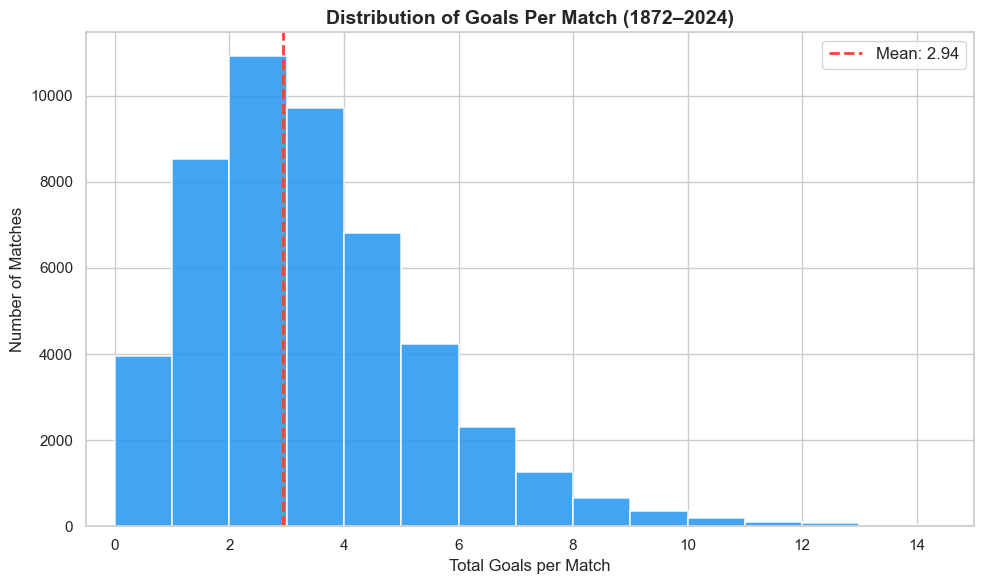

In [16]:
# Visualization 1: Histogram of goals
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['total_goals'], bins=range(0, int(df['total_goals'].max()) + 2), 
        edgecolor='white', color='#2196F3', alpha=0.85, linewidth=1.2)

# Add mean line
ax.axvline(df['total_goals'].mean(), color='#F44336', linestyle='--', linewidth=2, 
           label=f"Mean: {df['total_goals'].mean():.2f}")

ax.set_xlabel('Total Goals per Match', fontsize=12)
ax.set_ylabel('Number of Matches', fontsize=12)
ax.set_title('Distribution of Goals Per Match (1872–2024)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_xlim(-0.5, 15)

plt.tight_layout()
plt.show()

### Visualization 2: Bar Chart of Match Outcomes

This shows the proportion of Home Wins, Away Wins, and Draws across all matches.

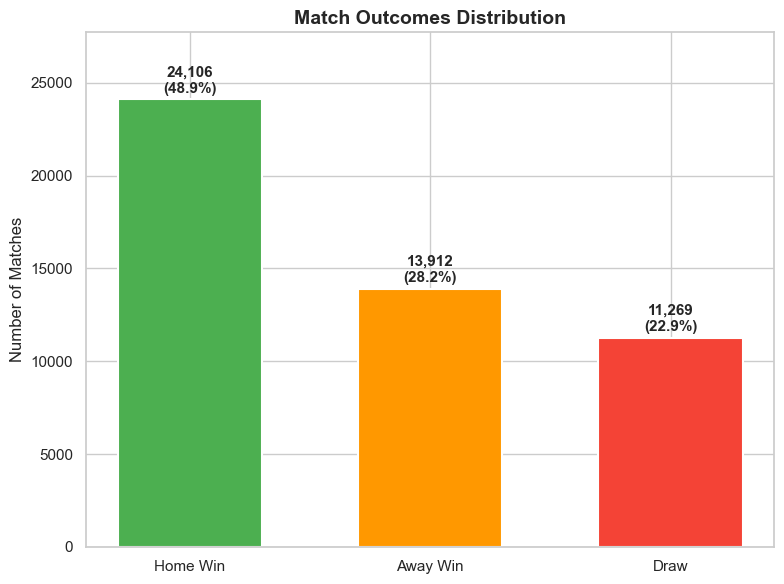

In [17]:
# Visualization 2: Match outcomes bar chart
fig, ax = plt.subplots(figsize=(8, 6))

result_counts = df['result'].value_counts()
colors = ['#4CAF50', '#FF9800', '#F44336']  # Green, Orange, Red
bars = ax.bar(result_counts.index, result_counts.values, color=colors, 
              edgecolor='white', linewidth=1.5, width=0.6)

# Add value labels on top of bars
for bar, count in zip(bars, result_counts.values):
    pct = (count / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Matches', fontsize=12)
ax.set_title('Match Outcomes Distribution', fontsize=14, fontweight='bold')
ax.set_ylim(0, result_counts.max() * 1.15)

plt.tight_layout()
plt.show()

### Visualization 3: Top 10 Teams by Total Wins

A horizontal bar chart showing the 10 most successful international football teams by total wins (home + away).

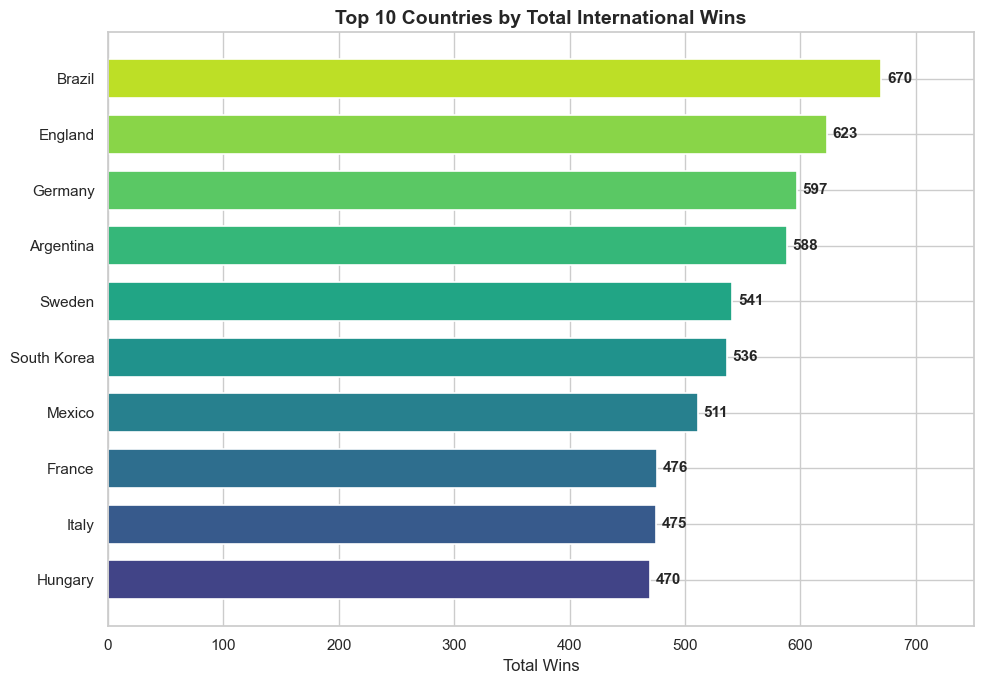

In [18]:
# Visualization 3: Top 10 teams by total wins
fig, ax = plt.subplots(figsize=(10, 7))

top10 = total_wins.head(10).sort_values()  # ascending for horizontal bar
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top10)))

bars = ax.barh(top10.index, top10.values, color=colors, edgecolor='white', linewidth=1.2, height=0.7)

# Add value labels
for bar, val in zip(bars, top10.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:,}', 
            va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Total Wins', fontsize=12)
ax.set_title('Top 10 Countries by Total International Wins', fontsize=14, fontweight='bold')
ax.set_xlim(0, top10.max() * 1.12)

plt.tight_layout()
plt.show()

### Bonus Visualization: Goals Trend Over Decades

How has the average number of goals per match changed over time?

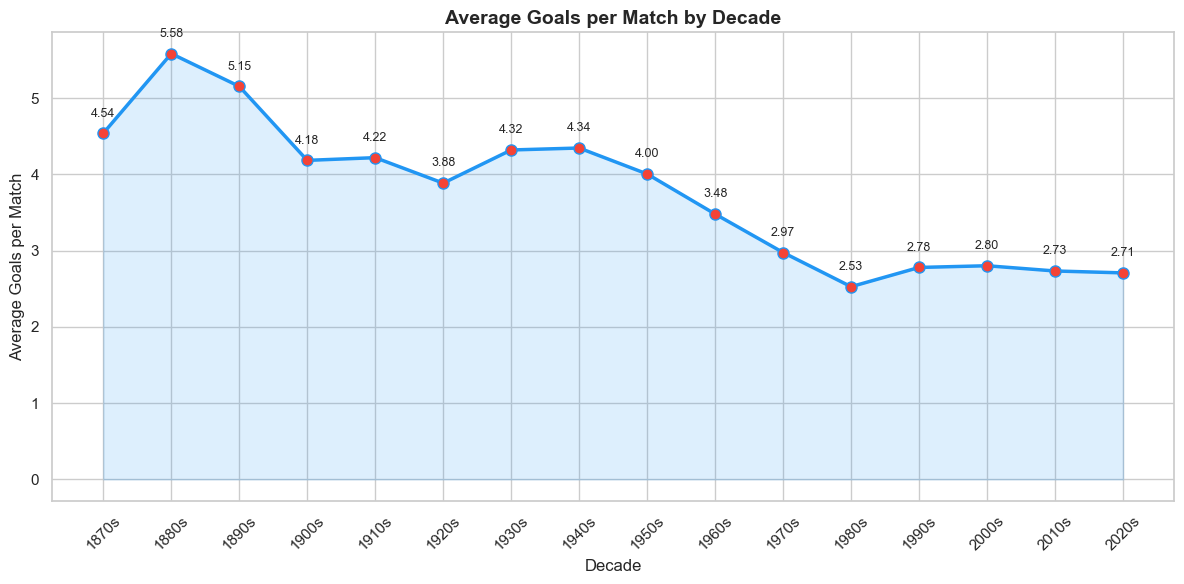

In [19]:
# Bonus: Goals trend over decades
df['decade'] = (df['year'] // 10) * 10
decade_goals = df.groupby('decade')['total_goals'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(decade_goals.index, decade_goals.values, marker='o', linewidth=2.5, 
        markersize=8, color='#2196F3', markerfacecolor='#F44336')
ax.fill_between(decade_goals.index, decade_goals.values, alpha=0.15, color='#2196F3')

ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Average Goals per Match', fontsize=12)
ax.set_title('Average Goals per Match by Decade', fontsize=14, fontweight='bold')
ax.set_xticks(decade_goals.index)
ax.set_xticklabels([f"{int(d)}s" for d in decade_goals.index], rotation=45)

for x, y in zip(decade_goals.index, decade_goals.values):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 12), 
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## Summary of Findings

### Basic Exploration
- The dataset contains **tens of thousands** of international football matches
- Data spans from **1872** to **2024** — over 150 years of football history
- Hundreds of unique countries have participated

### Goals Analysis
- The average number of goals per match is approximately **2.9**
- The most common scoreline total is **2 goals** per match
- Home teams consistently score more goals than away teams

### Match Results
- **Home advantage is real**: Home teams win significantly more often than away teams
- Home wins account for approximately **45%** of all matches
- Draws are the least common outcome at roughly **23%**

### Key Insight
The home advantage phenomenon is one of the most robust findings in sports analytics, and this dataset clearly confirms it for international football across 150+ years of history.